In [3]:
import pandas as pd
import pickle as pl
import pdb
import os
from sklearn.metrics import mean_squared_error
from statsmodels.stats.multitest import fdrcorrection
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from corrstats import dependent_corr
import sys
import re
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder


(-0.8912799047605414, 0.3749185174912557)
(1.0171097212822693, 0.3091012362386931)


In [59]:
# Load output from trained results
def evaluate_sig(data_path, input_genes=False, wsi=False, df=False):
    # df_list = []
    with open(data_path, 'rb') as f:
        test_res = pl.load(f)

    if wsi:
        df_real = test_res['real'].loc[wsi,:]
        df_pred = test_res['pred'].loc[wsi,:]
        df_random = test_res['random'].loc[wsi,:]
        
    else:
        df_real = test_res['real']
        df_pred = test_res['pred']
        df_random = test_res['random']
    
    if input_genes:
        genes = [gene for gene in test_res['real'].columns if gene in input_genes]
    # wsi = test_res['real'].index.values
    else:
        genes = [gene for gene in test_res['real'].columns]

    pred_r = []
    random_r = []
    test_p = []
    pearson_p = []
    rmse_pred= []
    rmse_random = []
    valid_genes = []

    for gene in genes:
        # Correlation test
        xy, p1 = stats.pearsonr(df_real.loc[:, gene], df_pred.loc[:, gene])
        xz, p2 = stats.pearsonr(df_real.loc[:, gene], df_random.loc[:, gene])
        yz, p3 = stats.pearsonr(df_pred.loc[:, gene], df_random.loc[:, gene])
        n = len(df_real.loc[:, gene])
        t, p = dependent_corr(xy, xz, yz, n, twotailed=False, conf_level=0.95, method='steiger')

        if None in (p1, p2, p3, p):
            continue

        pred_r.append(xy)
        random_r.append(xz)
        test_p.append(p)
        pearson_p.append(p1)

        # RMSE test
        rmse1 = mean_squared_error(df_real.loc[:, gene], df_pred.loc[:, gene],squared=False)
        rmse2 = mean_squared_error(df_real.loc[:, gene], df_random.loc[:, gene],squared=False)
        rmse_pred.append(rmse1)
        rmse_random.append(rmse2)
        valid_genes.append(gene)

    combine_res = pd.DataFrame({"pred_real_r": pred_r,\
                            "random_real_r": random_r,\
                            'pearson_p': pearson_p,\
                            "Steiger_p": test_p,\
                            'rmse_pred': rmse_pred, \
                            'rmse_random': rmse_random}, index=valid_genes)

    combine_res = combine_res.sort_values('pred_real_r', ascending = False)
    combine_res = combine_res[~combine_res['Steiger_p'].isna()]
    _, fdr_p = fdrcorrection(combine_res['Steiger_p'])
    combine_res['fdr_Steiger_p'] = fdr_p
        
    sig_res = combine_res[(combine_res['pred_real_r'] > 0) & \
                    (combine_res['pearson_p'] < 0.05) & \
                    (combine_res['pred_real_r'] > combine_res['random_real_r']) & \
                    (combine_res['Steiger_p'] < 0.05) & \
                    (combine_res['fdr_Steiger_p'] < 0.2)]

    print(f"Found {sig_res.shape[0]} significant genes")
    # if sig_res.shape[0] > 0:
    #     df_list.append(sig_res)
            
    # df_final = pd.concat(df_list)
    # df_final.to_csv(os.path.join(save_path, "sig_genes.csv"))

    # df_num_sig = df_final['cancer'].value_counts().reset_index()
    # df_num_sig.columns = ['cancer', 'num_genes']
    # df_num_sig.to_csv(os.path.join(save_path, "num_sign_genes.csv"))
    return sig_res


In [54]:
# Load output from trained results
def evaluate_sig_log2(data_path, input_genes, wsi=False):
    # df_list = []
    with open(data_path, 'rb') as f:
        test_res = pl.load(f)

    if wsi:
        df_real = np.log2(test_res['real'].loc[wsi,:] + 1)
        df_pred = test_res['pred'].loc[wsi,:]
        df_random = test_res['random'].loc[wsi,:]
        
    else:
        df_real = np.log2(test_res['real'] + 1)
        df_pred = test_res['pred']
        df_random = test_res['random']
    
    genes = [gene for gene in test_res['real'].columns if gene in input_genes]
    # wsi = test_res['real'].index.values

    pred_r = []
    random_r = []
    test_p = []
    pearson_p = []
    rmse_pred= []
    rmse_random = []
    valid_genes = []

    for gene in genes:
        # Correlation test
        xy, p1 = stats.pearsonr(df_real.loc[:, gene], df_pred.loc[:, gene])
        xz, p2 = stats.pearsonr(df_real.loc[:, gene], df_random.loc[:, gene])
        yz, p3 = stats.pearsonr(df_pred.loc[:, gene], df_random.loc[:, gene])
        n = len(df_real.loc[:, gene])
        t, p = dependent_corr(xy, xz, yz, n, twotailed=False, conf_level=0.95, method='steiger')

        if None in (p1, p2, p3, p):
            continue

        pred_r.append(xy)
        random_r.append(xz)
        test_p.append(p)
        pearson_p.append(p1)

        # RMSE test
        rmse1 = mean_squared_error(df_real.loc[:, gene], df_pred.loc[:, gene],squared=False)
        rmse2 = mean_squared_error(df_real.loc[:, gene], df_random.loc[:, gene],squared=False)
        rmse_pred.append(rmse1)
        rmse_random.append(rmse2)
        valid_genes.append(gene)

    combine_res = pd.DataFrame({"pred_real_r": pred_r,\
                            "random_real_r": random_r,\
                            'pearson_p': pearson_p,\
                            "Steiger_p": test_p,\
                            'rmse_pred': rmse_pred, \
                            'rmse_random': rmse_random}, index=valid_genes)

    combine_res = combine_res.sort_values('pred_real_r', ascending = False)
    combine_res = combine_res[~combine_res['Steiger_p'].isna()]
    _, fdr_p = fdrcorrection(combine_res['Steiger_p'])
    combine_res['fdr_Steiger_p'] = fdr_p
        
    sig_res = combine_res[(combine_res['pred_real_r'] > 0) & \
                    (combine_res['pearson_p'] < 0.05) & \
                    (combine_res['pred_real_r'] > combine_res['random_real_r']) & \
                    (combine_res['Steiger_p'] < 0.05) & \
                    (combine_res['fdr_Steiger_p'] < 0.2)]

    print(f"Found {sig_res.shape[0]} significant genes")
    # if sig_res.shape[0] > 0:
    #     df_list.append(sig_res)
            
    # df_final = pd.concat(df_list)
    # df_final.to_csv(os.path.join(save_path, "sig_genes.csv"))

    # df_num_sig = df_final['cancer'].value_counts().reset_index()
    # df_num_sig.columns = ['cancer', 'num_genes']
    # df_num_sig.to_csv(os.path.join(save_path, "num_sign_genes.csv"))
    return sig_res


In [53]:
data_path = '/data/tjung/ALMAC/processed_data/stringtie_exp_mat_TPM.csv'
ALMAC_exp_df = pd.read_csv(data_path, index_col=0)
input_genes = ALMAC_exp_df.columns

In [43]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res = evaluate_sig(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2119 significant genes


In [4]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_log2 = evaluate_sig_log2(data_path=data_path, input_genes=input_genes)

NameError: name 'input_genes' is not defined

In [12]:
# PCA plot
# For all genes
with open(data_path, 'rb') as f:
    test_res = pl.load(f)

# Create labels
type = 'MLN	MLN	MLN	MLN	MLN	NL	RP	RP	NL	RP	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	RP	RP	RP	RP	MLN	MLN	MLN	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	MLN	RP	RP	RP	RP	RP	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	NL	RP	RP	RP	RP	RP	NL	RP	RP	RP	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	MLN	MLN	RP	RP	RP	RP	RP	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP'.split('\t')
le = LabelEncoder()
le.fit(type)
type = le.transform(type)

df_real = test_res['real']
df_pred = test_res['pred']

pca = PCA(n_components=2)
X_pca_real = pca.fit_transform(df_real)
X_pca_real_sig = pca.fit_transform(df_real.loc[:,sig_res.index])
X_pca_pred = pca.fit_transform(df_pred)
X_pca_pred_sig = pca.fit_transform(df_pred.loc[:,sig_res.index])


fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0][0].scatter(X_pca_real[:, 0], X_pca_real[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[0][0].set_title('(Real) PCA of ALMAC (n=18,106)')
ax[0][0].set_xlabel('Principal Component 1')
ax[0][0].set_ylabel('Principal Component 2')

ax[0][1].scatter(X_pca_real_sig[:, 0], X_pca_real_sig[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[0][1].set_title('(Real) PCA of ALMAC (n=2119) sig genes')
ax[0][1].set_xlabel('Principal Component 1')
ax[0][1].set_ylabel('Principal Component 2')

ax[1][0].scatter(X_pca_pred[:, 0], X_pca_pred[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[1][0].set_title('(Predicted) PCA of ALMAC (n=18,106)')
ax[1][0].set_xlabel('Principal Component 1')
ax[1][0].set_ylabel('Principal Component 2')

ax[1][1].scatter(X_pca_pred_sig[:, 0], X_pca_pred_sig[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[1][1].set_title('(Predicted) PCA of ALMAC (n=2119) sig genes')
ax[1][1].set_xlabel('Principal Component 1')
ax[1][1].set_ylabel('Principal Component 2')

labels = np.unique(type)

NameError: name 'sig_res' is not defined

In [13]:
df_pred

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
HR-ID1-MLN1,0.051808,0.234409,0.076554,5.741102,0.595164,0.362677,0.086978,2.684270,0.025396,3.460134,...,1.768103,2.480550,1.484950,2.397854,2.688508,1.192838,2.864270,4.713716,2.625959,2.822507
HR-ID1-MLN2,0.047867,0.252741,0.101622,6.097449,0.786176,0.255954,0.085527,2.996125,0.015033,3.490419,...,1.614565,2.424644,1.366948,2.265519,2.713835,0.763527,2.872205,5.115701,2.603275,2.750520
HR-ID1-MLN3,0.036593,0.204157,0.137187,6.185684,0.755871,0.365013,0.082399,2.725488,0.029950,3.414336,...,1.668360,2.576664,1.459824,2.337286,2.695884,0.860945,2.951059,4.894824,2.601196,2.821660
HR-ID1-MLN4,0.042336,0.219088,0.122898,6.172845,0.684965,0.309010,0.090331,2.818955,0.031917,3.417958,...,1.675845,2.503511,1.438978,2.326511,2.708493,1.050444,2.846380,5.043998,2.536685,2.746766
HR-ID1-MLN5,0.050588,0.254386,0.081201,5.915328,0.556305,0.263695,0.089516,2.408681,0.037976,3.318549,...,1.775059,2.722419,1.517183,2.409216,2.799347,0.964458,2.948147,4.839968,2.577793,2.804211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR-ID25-MLN2,0.028719,0.199955,0.166183,5.910428,0.721769,0.363302,0.078108,3.291133,0.017905,3.759461,...,1.484988,2.422267,1.066979,1.951109,2.438278,0.857809,2.592164,5.078059,2.315208,2.616879
HR-ID25-MLN3,0.026797,0.160728,0.062925,5.322495,0.639425,0.277228,0.091217,2.850822,0.029212,3.808403,...,1.644272,2.718421,1.124398,2.011613,2.595091,0.983350,2.595382,4.653284,2.425086,2.660604
HR-ID25-NL,0.027485,0.170474,0.085102,6.380520,0.754582,0.340174,0.084674,3.361219,0.030851,3.641214,...,1.499414,2.431334,1.153926,2.018090,2.356205,0.787537,2.642832,5.408343,2.327023,2.688772
HR-ID25-RP3,0.013222,0.181673,0.160426,6.203360,0.704305,0.363662,0.075705,3.024174,0.023423,3.636002,...,1.572863,2.548952,1.229317,2.057080,2.504011,0.993137,2.763035,5.037370,2.421095,2.722278


In [38]:
samples_118 = [sample.replace('_', '-') for sample in 'HR_ID1_MLN1	HR_ID1_MLN2	HR_ID1_MLN3	HR_ID1_MLN4	HR_ID1_MLN5	HR_ID1_RP1	HR_ID3_MLN1	HR_ID3_MLN2	HR_ID3_MLN3	HR_ID3_NL	HR_ID3_RP1	HR_ID3_RP2	HR_ID3_RP3	HR_ID3_RP4	HR_ID3_RP5	HR_ID4_MLN1	HR_ID4_MLN2	HR_ID4_MLN3	HR_ID4_RP1	HR_ID4_RP2	HR_ID4_RP4	HR_ID4_RP5	HR_ID5_MLN1	HR_ID5_MLN2	HR_ID5_MLN3	HR_ID5_RP1	HR_ID5_RP2	HR_ID5_RP4	HR_ID6_MLN1	HR_ID6_MLN2	HR_ID6_MLN3	HR_ID6_RP1	HR_ID6_RP2	HR_ID6_RP3	HR_ID7_MLN1	HR_ID7_MLN2	HR_ID7_MLN3	HR_ID7_NL	HR_ID7_RP1	HR_ID7_RP2	HR_ID7_RP3	HR_ID7_RP4	HR_ID7_RP5	HR_ID7_RP6	HR_ID9_MLN1	HR_ID9_MLN2	HR_ID9_RP1	HR_ID9_RP2	HR_ID10_MLN1	HR_ID10_MLN2	HR_ID10_NL	HR_ID10_RP1	HR_ID10_RP2	HR_ID10_RP3	HR_ID10_RP4	HR_ID10_RP5	HR_ID10_RP6	HR_ID11_MLN1	HR_ID11_NL	HR_ID11_RP1	HR_ID11_RP2	HR_ID11_RP3	HR_ID11_RP4	HR_ID11_RP5	HR_ID15_MLN1	HR_ID15_MLN2	HR_ID15_RP5	HR_ID17_MLN2	HR_ID17_MLN3	HR_ID17_NL	HR_ID17_RP1	HR_ID17_RP2	HR_ID17_RP3	HR_ID17_RP4	HR_ID17_RP5	HR_ID17_RP6	HR_ID18_MLN1	HR_ID18_MLN2	HR_ID18_MLN3	HR_ID18_MLN4	HR_ID18_NL	HR_ID18_RP1	HR_ID18_RP2	HR_ID18_RP3	HR_ID18_RP4	HR_ID18_RP5	HR_ID19_MLN1	HR_ID19_MLN2	HR_ID19_MLN3	HR_ID19_MLN4	HR_ID19_MLN5	HR_ID19_RP2	HR_ID19_RP5	HR_ID19_RP6	HR_ID24_MLN10	HR_ID24_MLN11	HR_ID24_MLN12	HR_ID24_MLN13	HR_ID24_MLN2	HR_ID24_MLN3	HR_ID24_MLN4	HR_ID24_MLN5	HR_ID24_MLN6	HR_ID24_MLN7	HR_ID24_MLN8	HR_ID24_MLN9	HR_ID24_NL	HR_ID24_RP1	HR_ID24_RP2	HR_ID24_RP3	HR_ID24_RP4	HR_ID24_RP5	HR_ID25_MLN1	HR_ID25_MLN2	HR_ID25_MLN3	HR_ID25_NL	HR_ID25_RP3	HR_ID25_RP4'.split('\t')]

In [40]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_118 = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=samples_118)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2199 significant genes


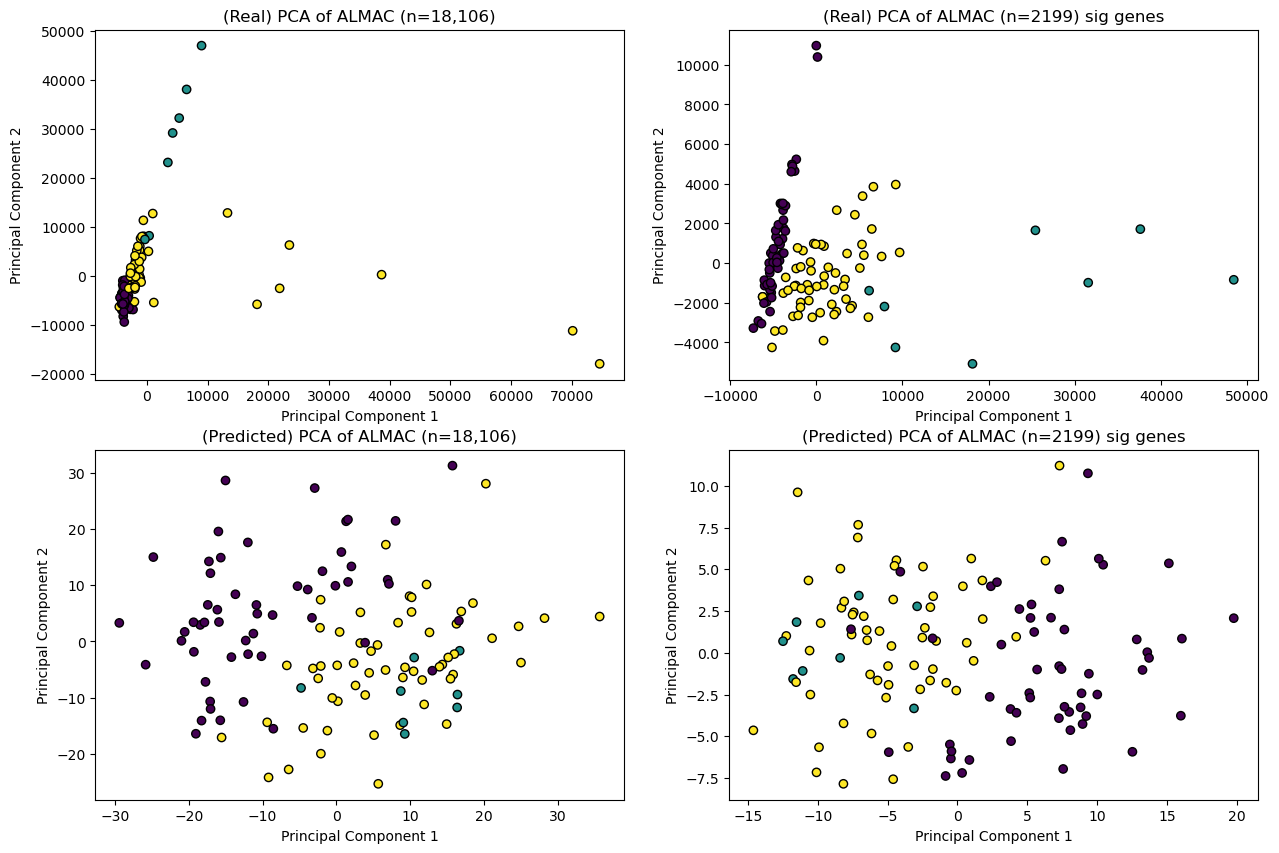

In [50]:
# PCA plot
# For all genes
with open(data_path, 'rb') as f:
    test_res = pl.load(f)

# Create labels
type = 'MLN	MLN	MLN	MLN	MLN	RP	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	RP	RP	RP	RP	MLN	MLN	MLN	RP	RP	RP	MLN	MLN	MLN	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	MLN	RP	RP	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	RP	MLN	MLN	NL	RP	RP	RP	RP	RP	RP	MLN	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	MLN	MLN	RP	RP	RP	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	MLN	NL	RP	RP	RP	RP	RP	MLN	MLN	MLN	NL	RP	RP'.split('\t')
le = LabelEncoder()
le.fit(type)
type = le.transform(type)

df_real = test_res['real'][test_res['real'].index.isin(samples_118)]
df_pred = test_res['pred'][test_res['pred'].index.isin(samples_118)]

pca = PCA(n_components=2)
X_pca_real = pca.fit_transform(df_real)
X_pca_real_sig = pca.fit_transform(df_real.loc[:,sig_res_118.index])
X_pca_pred = pca.fit_transform(df_pred)
X_pca_pred_sig = pca.fit_transform(df_pred.loc[:,sig_res_118.index])


fig, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0][0].scatter(X_pca_real[:, 0], X_pca_real[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[0][0].set_title('(Real) PCA of ALMAC (n=18,106)')
ax[0][0].set_xlabel('Principal Component 1')
ax[0][0].set_ylabel('Principal Component 2')

ax[0][1].scatter(X_pca_real_sig[:, 0], X_pca_real_sig[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[0][1].set_title('(Real) PCA of ALMAC (n=2199) sig genes')
ax[0][1].set_xlabel('Principal Component 1')
ax[0][1].set_ylabel('Principal Component 2')

ax[1][0].scatter(X_pca_pred[:, 0], X_pca_pred[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[1][0].set_title('(Predicted) PCA of ALMAC (n=18,106)')
ax[1][0].set_xlabel('Principal Component 1')
ax[1][0].set_ylabel('Principal Component 2')

ax[1][1].scatter(X_pca_pred_sig[:, 0], X_pca_pred_sig[:, 1], c=type, cmap='viridis', edgecolor='k')
ax[1][1].set_title('(Predicted) PCA of ALMAC (n=2199) sig genes')
ax[1][1].set_xlabel('Principal Component 1')
ax[1][1].set_ylabel('Principal Component 2')

labels = np.unique(type)

In [79]:
le.classes_

array(['MLN', 'NL', 'RP'], dtype='<U3')

In [56]:
NL_samples_118 = [i.replace('_', '-') for i in 'HR_ID3_NL	HR_ID7_NL	HR_ID10_NL	HR_ID11_NL	HR_ID17_NL	HR_ID18_NL	HR_ID24_NL	HR_ID25_NL'.split('\t')]
MLN_samples_118 = [i.replace('_', '-') for i in 'HR_ID1_MLN1	HR_ID1_MLN2	HR_ID1_MLN3	HR_ID1_MLN4	HR_ID1_MLN5	HR_ID3_MLN1	HR_ID3_MLN2	HR_ID3_MLN3	HR_ID4_MLN1	HR_ID4_MLN2	HR_ID4_MLN3	HR_ID5_MLN1	HR_ID5_MLN2	HR_ID5_MLN3	HR_ID6_MLN1	HR_ID6_MLN2	HR_ID6_MLN3	HR_ID7_MLN1	HR_ID7_MLN2	HR_ID7_MLN3	HR_ID9_MLN1	HR_ID9_MLN2	HR_ID10_MLN1	HR_ID10_MLN2	HR_ID11_MLN1	HR_ID15_MLN1	HR_ID15_MLN2	HR_ID17_MLN2	HR_ID17_MLN3	HR_ID18_MLN1	HR_ID18_MLN2	HR_ID18_MLN3	HR_ID18_MLN4	HR_ID19_MLN1	HR_ID19_MLN2	HR_ID19_MLN3	HR_ID19_MLN4	HR_ID19_MLN5	HR_ID24_MLN10	HR_ID24_MLN11	HR_ID24_MLN12	HR_ID24_MLN13	HR_ID24_MLN2	HR_ID24_MLN3	HR_ID24_MLN4	HR_ID24_MLN5	HR_ID24_MLN6	HR_ID24_MLN7	HR_ID24_MLN8	HR_ID24_MLN9	HR_ID25_MLN1	HR_ID25_MLN2	HR_ID25_MLN3'.split('\t')]
RP_samples_118 = [i.replace('_', '-') for i in 'HR_ID1_RP1	HR_ID3_RP1	HR_ID3_RP2	HR_ID3_RP3	HR_ID3_RP4	HR_ID3_RP5	HR_ID4_RP1	HR_ID4_RP2	HR_ID4_RP4	HR_ID4_RP5	HR_ID5_RP1	HR_ID5_RP2	HR_ID5_RP4	HR_ID6_RP1	HR_ID6_RP2	HR_ID6_RP3	HR_ID7_RP1	HR_ID7_RP2	HR_ID7_RP3	HR_ID7_RP4	HR_ID7_RP5	HR_ID7_RP6	HR_ID9_RP1	HR_ID9_RP2	HR_ID10_RP1	HR_ID10_RP2	HR_ID10_RP3	HR_ID10_RP4	HR_ID10_RP5	HR_ID10_RP6	HR_ID11_RP1	HR_ID11_RP2	HR_ID11_RP3	HR_ID11_RP4	HR_ID11_RP5	HR_ID15_RP5	HR_ID17_RP1	HR_ID17_RP2	HR_ID17_RP3	HR_ID17_RP4	HR_ID17_RP5	HR_ID17_RP6	HR_ID18_RP1	HR_ID18_RP2	HR_ID18_RP3	HR_ID18_RP4	HR_ID18_RP5	HR_ID19_RP2	HR_ID19_RP5	HR_ID19_RP6	HR_ID24_RP1	HR_ID24_RP2	HR_ID24_RP3	HR_ID24_RP4	HR_ID24_RP5	HR_ID25_RP3	HR_ID25_RP4'.split('\t')]

In [59]:
len(NL_samples_118 + RP_samples_118)

65

In [57]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_NL_RP_118 = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=NL_samples_118+RP_samples_118)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 261 significant genes


In [58]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_MLN_118 = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=MLN_samples_118)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 465 significant genes


In [62]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results_all_patches.pkl"
sig_res_all_patches = evaluate_sig(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2146 significant genes


In [17]:
NL_samples = [i.replace('_', '-') for i in 'HR_ID1_NL	HR_ID2_NL	HR_ID3_NL	HR_ID6_NL	HR_ID7_NL	HR_ID10_NL	HR_ID11_NL	HR_ID15_NL	HR_ID16_NL	HR_ID17_NL	HR_ID18_NL	HR_ID24_NL	HR_ID25_NL'.split('\t')]
RP_samples = [i.replace('_', '-') for i in 'HR_ID1_RP1	HR_ID1_RP5	HR_ID2_RP2	HR_ID2_RP3	HR_ID2_RP4	HR_ID2_RP5	HR_ID3_RP1	HR_ID3_RP2	HR_ID3_RP3	HR_ID3_RP4	HR_ID3_RP5	HR_ID4_RP1	HR_ID4_RP2	HR_ID4_RP4	HR_ID4_RP5	HR_ID5_RP1	HR_ID5_RP2	HR_ID5_RP4	HR_ID6_RP1	HR_ID6_RP2	HR_ID6_RP3	HR_ID6_RP4	HR_ID7_RP1	HR_ID7_RP2	HR_ID7_RP3	HR_ID7_RP4	HR_ID7_RP5	HR_ID7_RP6	HR_ID9_RP1	HR_ID9_RP2	HR_ID9_RP3	HR_ID9_RP4	HR_ID9_RP5	HR_ID10_RP1	HR_ID10_RP2	HR_ID10_RP3	HR_ID10_RP4	HR_ID10_RP5	HR_ID10_RP6	HR_ID11_RP1	HR_ID11_RP2	HR_ID11_RP3	HR_ID11_RP4	HR_ID11_RP5	HR_ID15_RP1	HR_ID15_RP2	HR_ID15_RP3	HR_ID15_RP4	HR_ID15_RP5	HR_ID16_RP3	HR_ID16_RP4	HR_ID16_RP5	HR_ID17_RP1	HR_ID17_RP2	HR_ID17_RP3	HR_ID17_RP4	HR_ID17_RP5	HR_ID17_RP6	HR_ID18_RP1	HR_ID18_RP2	HR_ID18_RP3	HR_ID18_RP4	HR_ID18_RP5	HR_ID19_RP1	HR_ID19_RP2	HR_ID19_RP4	HR_ID19_RP5	HR_ID19_RP6	HR_ID24_RP1	HR_ID24_RP2	HR_ID24_RP3	HR_ID24_RP4	HR_ID24_RP5	HR_ID25_RP3	HR_ID25_RP4'.split('\t')]
MLN_samples = [i.replace('_', '-') for i in 'HR_ID1_MLN1	HR_ID1_MLN2	HR_ID1_MLN3	HR_ID1_MLN4	HR_ID1_MLN5	HR_ID3_MLN1	HR_ID3_MLN2	HR_ID3_MLN3	HR_ID4_MLN1	HR_ID4_MLN2	HR_ID4_MLN3	HR_ID5_MLN1	HR_ID5_MLN2	HR_ID5_MLN3	HR_ID6_MLN1	HR_ID6_MLN2	HR_ID6_MLN3	HR_ID7_MLN1	HR_ID7_MLN2	HR_ID7_MLN3	HR_ID9_MLN1	HR_ID9_MLN2	HR_ID10_MLN1	HR_ID10_MLN2	HR_ID11_MLN1	HR_ID15_MLN1	HR_ID15_MLN2	HR_ID17_MLN2	HR_ID17_MLN3	HR_ID18_MLN1	HR_ID18_MLN2	HR_ID18_MLN3	HR_ID18_MLN4	HR_ID19_MLN1	HR_ID19_MLN2	HR_ID19_MLN3	HR_ID19_MLN4	HR_ID19_MLN5	HR_ID24_MLN10	HR_ID24_MLN11	HR_ID24_MLN12	HR_ID24_MLN13	HR_ID24_MLN2	HR_ID24_MLN3	HR_ID24_MLN4	HR_ID24_MLN5	HR_ID24_MLN6	HR_ID24_MLN7	HR_ID24_MLN8	HR_ID24_MLN9	HR_ID25_MLN1	HR_ID25_MLN2	HR_ID25_MLN3'.split('\t')]

In [18]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_NL = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=NL_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 0 significant genes


In [19]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_RP = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=RP_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 397 significant genes


In [20]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results.pkl"
sig_res_MLN = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=MLN_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 465 significant genes


In [24]:
sig_res_RP[sig_res_RP.index.isin(sig_res_MLN.index)].index

Index(['PNPLA6', 'POLR1E', 'GOLGA7B', 'IGFBP6', 'C1QL3', 'KIF18B', 'RBBP4',
       'HSPB6', 'EPHB3'],
      dtype='object')

In [27]:
len(RP_samples)

75

In [21]:
sig_res_NL_RP = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=NL_samples+RP_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 611 significant genes


In [19]:
sig_res_RP_MLN = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=MLN_samples+RP_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 1963 significant genes


In [63]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results_all_patches.pkl"
sig_res_NL_RP_all_patches = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=NL_samples+RP_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 725 significant genes


In [64]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results_all_patches.pkl"
sig_res_MLN_all_patches = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=MLN_samples)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 341 significant genes


In [65]:
sig_res_MLN_all_patches[sig_res_MLN_all_patches.index.isin(sig_res_NL_RP_all_patches.index)].index

Index(['GABARAPL1', 'ORC1', 'KIF18B', 'WLS', 'TICRR', 'HERPUD1', 'FBXO31',
       'MEG3', 'NCS1', 'WWTR1', 'NFATC4', 'EGFL6', 'ABTB1', 'TNS2', 'CYYR1',
       'IGFBP6', 'PDLIM7', 'TCEAL1', 'HTATSF1', 'CSRP1', 'RUSC2', 'GSN',
       'COL6A2', 'C1QL3'],
      dtype='object')

In [33]:
len(NL_samples + RP_samples)

88

In [14]:
sig_res_RP

NameError: name 'sig_res_RP' is not defined

In [32]:
sig_res_MLN[sig_res_MLN.index.isin(sig_res_NL_RP.index)].index

Index(['GABARAPL1', 'PYGB', 'KIF18B', 'ENPP1', 'NCS1', 'FBXO31', 'WWTR1',
       'CYYR1', 'RNF166', 'GOLGA7B', 'EGFL6', 'IGFBP6', 'DENND4B', 'PNPLA6',
       'GJC3', 'C1QL3', 'MEG3', 'RBBP4', 'MPI', 'SLFNL1-AS1', 'BAIAP2',
       'HSPB6', 'RUSC2'],
      dtype='object')

In [54]:
[i for i in sig_res_prostate.index if i in sig_res_node.index]

['NUDT15',
 'CRLF3',
 'DUOXA1',
 'GABARAPL1',
 'PPM1E',
 'ANG',
 'CMAS',
 'CDK5R1',
 'ALDH5A1',
 'GPC4',
 'PKD1L3']

In [25]:
df_TCGA_sig_genes = pd.read_csv('/data/tjung/thesis2023/sequoia_code/gene_list/TCGA_sign_genes_prad.csv', index_col=0)
df_TCGA_sig_genes = df_TCGA_sig_genes[df_TCGA_sig_genes['gene_id'].isin(ALMAC_exp_df.columns)]
df_TCGA_sig_genes.shape

(7757, 1)

In [66]:
np.sum(sig_res_all_patches.index.isin(df_TCGA_sig_genes['gene_id']))

1291

In [32]:
df_sign_lumin

,0
0,SNHG8
1,PRAC1
2,ENTPD5
3,HJURP
4,DEPDC1B
5,CENPK
6,KIFC1
7,NEK2
8,SNRNP25
9,DTYMK


In [30]:
df_sign_fibro = pd.read_csv('/data/tjung/thesis2023/sequoia_code/gene_list/DE_genes_sign_fibro.csv', header=None)
df_sign_lumin = pd.read_csv('/data/tjung/thesis2023/sequoia_code/gene_list/DE_genes_sign_luminal.csv', header=None)

# Fibroblast
print(len([ gene for gene in sig_res_RP.index if gene in set(df_sign_fibro[0].to_list())]))
print([ gene for gene in sig_res_RP.index if gene in set(df_sign_fibro[0].to_list())])

# Luminal
print(len([ gene for gene in sig_res_RP.index if gene in set(df_sign_lumin[0].to_list())]))
print([ gene for gene in sig_res_RP.index if gene in set(df_sign_lumin[0].to_list())])

1
['IGFBP6']
0
[]


In [55]:
x = ['C1R', 'IGFBP6', 'SMARCD3', 'BOC', 'CERCAM', 'TAGLN', 'PCOLCE', 'PRELP', 'SERPINF1', 'MATN2', 'RBPMS', 'TGFB1I1', 'P3H3', 'INMT', 'NHSL2', 'S100A6', 'WFDC1', 'PCP4', 'GSN', 'TINAGL1', 'DIO3OS', 'PDGFRL', 'COL15A1', 'TPM2', 'GPX3', 'CRABP2', 'ELN', 'TNS1', 'PLXDC2', 'MSRB3', 'FOXC1', 'CNN1', 'MYLK', 'TWIST2', 'FLNA', 'COX7A1', 'JDP2', 'HSPB8', 'SSC5D', 'LRP1', 'FBLN5', 'MT1E', 'TBX2', 'KCNAB1', 'SPON1', 'IGFBP7', 'RASL11A', 'CDO1', 'ITGA8', 'NDRG2', 'LPAR1', 'NT5E', 'CFD', 'PDGFRA', 'RNF152', 'RHOB', 'F2R', 'DLL1', 'FGF7']

print([ gene for gene in x if gene in set(df_sign_lumin[0].to_list())])

['CRABP2']


In [34]:
[gene for gene in [ gene for gene in sig_res.index if gene in set(df_sign_fibro[0].to_list())] if gene in [ gene for gene in sig_res.index if gene in set(df_sign_lumin[0].to_list())]]

['CRABP2']

In [23]:
print(sig_res_MLN.shape)
df_sign_fibro = pd.read_csv('/data/tjung/thesis2023/sequoia_code/gene_list/DE_genes_sign_fibro.csv', header=None)
df_sign_lumin = pd.read_csv('/data/tjung/thesis2023/sequoia_code/gene_list/DE_genes_sign_luminal.csv', header=None)

# Fibroblast
print(len([ gene for gene in sig_res_MLN.index if gene in set(df_sign_fibro[0].to_list())]))
print([ gene for gene in sig_res_MLN.index if gene in set(df_sign_fibro[0].to_list())])

# Luminal
print(len([ gene for gene in sig_res_MLN.index if gene in set(df_sign_lumin[0].to_list())]))
print([ gene for gene in sig_res_MLN.index if gene in set(df_sign_lumin[0].to_list())])

(465, 7)
10
['TNS1', 'TBX2', 'WFDC1', 'LRP1', 'BOC', 'GPX3', 'NHSL2', 'IGFBP6', 'TWIST2', 'GSN']
11
['TPX2', 'BUB1', 'TOP2A', 'KIF4A', 'HJURP', 'DEPDC1B', 'ASPM', 'MCM4', 'LMNB1', 'KIFC1', 'UBE2C']


In [117]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231110_test_results.pkl'
sig_res_annot = evaluate_sig(data_path=data_path, input_genes=input_genes, wsi=os.listdir('/data/tjung/ALMAC/patches_full/'))

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 934 significant genes


In [103]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231113_test_results.pkl'
sig_res_full = evaluate_sig(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 823 significant genes


In [120]:
len([gene for gene in sig_res_annot.index if gene in sig_res_full.index])

418

In [35]:
data_path_merged = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231203_test_results_merged.pkl'

with open(data_path_merged, 'rb') as f:
    test_res = pl.load(f)

    df_real = np.log2(test_res['real'] + 1)
    df_pred_merged = test_res['pred']
    df_random_merged = test_res['random']

In [38]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231120_test_results_all_patches.pkl'

with open(data_path, 'rb') as f:
    test_res = pl.load(f)

    df_real = np.log2(test_res['real'] + 1)
    df_pred = test_res['pred']
    df_random = test_res['random']

In [45]:
df_pred_merged[df_pred_merged.index.isin(['HR-ID1-RP5 NL.ndpi', 'HR-ID2-RP5 NL.ndpi', 'HR-ID6-RP4.ndpi',
       'HR-ID16-RP3 NL - 2022-09-12 10.45.09.ndpi'])]

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,ZNF710-AS1,ZNF724,ZNF775-AS1,ZNF8-ERVK3-1,ZNF875,ZNNT1,ZNRD2,ZNRD2-AS1,ZSWIM9,ZUP1
HR-ID1-RP5 NL.ndpi,0.001029,0.227610,0.052860,6.588165,0.796747,0.499523,0.070412,3.043007,0.031111,3.505920,...,1.515969,2.541502,1.258864,2.076524,2.521102,0.784834,2.856087,5.195609,2.497511,2.861773
HR-ID2-RP5 NL.ndpi,-0.009719,0.151166,0.061700,6.460154,0.674807,0.485714,0.061453,2.916989,0.026483,3.495324,...,1.711489,2.894748,1.211884,2.073845,2.358568,1.063056,2.743545,5.157693,2.308671,2.716163
HR-ID6-RP4.ndpi,0.018841,0.172625,0.111972,6.155326,0.826492,0.368139,0.083788,3.087253,0.034481,3.552378,...,1.556368,2.491726,1.283868,2.149192,2.472889,0.762889,2.770137,5.075002,2.505418,2.784134
HR-ID16-RP3 NL - 2022-09-12 10.45.09.ndpi,0.040616,0.213235,0.046922,6.324042,0.864416,0.399137,0.067501,3.150697,0.045420,3.478004,...,1.524743,2.315513,1.364041,2.153437,2.461261,0.820021,2.891520,5.156181,2.490343,2.820501


In [44]:
wsi = ['HR-ID1-RP5', 'HR-ID2-RP5', 'HR-ID6-RP4', 'HR-ID16-RP3']
df_pred[df_pred.index.isin(wsi)]

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
HR-ID1-RP5,0.022241,0.179002,0.050535,5.352567,0.604310,0.246927,0.081765,2.865646,0.022716,3.803824,...,1.540926,2.734940,1.024970,1.899928,2.461704,0.966937,2.465837,4.777968,2.195954,2.588444
HR-ID2-RP5,0.005696,0.135392,-0.023323,5.828731,0.540418,0.533032,0.078432,2.709044,0.008839,3.620560,...,1.770669,2.804375,1.168508,1.955556,2.524413,1.392653,2.574531,4.739586,2.204828,2.677898
HR-ID6-RP4,0.039162,0.188067,0.057648,6.226127,0.883032,0.380711,0.067219,3.217683,0.032688,3.569985,...,1.535811,2.384356,1.258194,2.116147,2.551940,0.776271,2.753474,5.205784,2.493370,2.685839
HR-ID16-RP3,0.029117,0.194468,0.171343,6.603955,0.844006,0.416707,0.063606,3.047281,0.032018,3.431283,...,1.603750,2.415379,1.343005,2.133690,2.491045,0.890877,2.949654,5.170987,2.469411,2.853817


In [47]:
from sklearn.metrics import mean_squared_error

In [49]:
mean_squared_error(df_real.loc['HR-ID1-RP5',:], df_pred.loc['HR-ID1-RP5',:])

2.4739740811750175

In [51]:
mean_squared_error(df_real.loc['HR-ID1-RP5',:], df_pred.loc['HR-ID1-RP5',:])

2.4739740811750175

Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A3GALT2',
       'A4GALT', 'A4GNT', 'AAAS',
       ...
       'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=25587)

In [68]:
mean_squared_error(df_real.loc['HR-ID1-RP5',:], df_pred.loc['HR-ID1-RP5',:])

2.4739740811750175

In [64]:
mean_squared_error(df_real.loc['HR-ID1-RP5',:], df_pred_merged.loc['HR-ID1-RP5 NL.ndpi', df_pred.columns])

9.570357752511907

In [69]:
from scipy.stats import pearsonr

In [72]:
corr, _ = pearsonr(df_real.loc['HR-ID1-RP5',:], df_pred.loc['HR-ID1-RP5',:])
corr

0.7337992738565682

In [73]:
corr, _ = pearsonr(df_real.loc['HR-ID1-RP5',:], df_pred_merged.loc['HR-ID1-RP5 NL.ndpi', df_pred.columns])
corr

-0.17662041414836016

In [19]:
data_path = "/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231208_test_results_TCGA.pkl"
sig_res = evaluate_sig(data_path=data_path)

Found 10816 significant genes


In [48]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/'

df_real, df_pred, df_random = [], [], []

for i in range(5):
    with open(data_path+f'{i}_test_results.pkl', 'rb') as f:
        test_res = pl.load(f)
        df_real.append(pd.DataFrame(test_res['real']))
        df_pred.append(pd.DataFrame(test_res['pred']))
        df_random.append(pd.DataFrame(test_res['random']))
        f.close()

df_real = pd.concat(df_real)
df_pred = pd.concat(df_pred)
df_random = pd.concat(df_random)

In [49]:
pred_r = []
random_r = []
test_p = []
pearson_p = []
rmse_pred= []
rmse_random = []
valid_genes = []

genes = df_pred.columns.values

for gene in genes:
    # Correlation test
    xy, p1 = stats.pearsonr(df_real.loc[:, gene], df_pred.loc[:, gene])
    xz, p2 = stats.pearsonr(df_real.loc[:, gene], df_random.loc[:, gene])
    yz, p3 = stats.pearsonr(df_pred.loc[:, gene], df_random.loc[:, gene])
    n = len(df_real.loc[:, gene])
    t, p = dependent_corr(xy, xz, yz, n, twotailed=False, conf_level=0.95, method='steiger')

    if None in (p1, p2, p3, p):
        continue

    pred_r.append(xy)
    random_r.append(xz)
    test_p.append(p)
    pearson_p.append(p1)

    # RMSE test
    rmse1 = mean_squared_error(df_real.loc[:, gene], df_pred.loc[:, gene],squared=False)
    rmse2 = mean_squared_error(df_real.loc[:, gene], df_random.loc[:, gene],squared=False)
    rmse_pred.append(rmse1)
    rmse_random.append(rmse2)
    valid_genes.append(gene)

combine_res = pd.DataFrame({"pred_real_r": pred_r,\
                        "random_real_r": random_r,\
                        'pearson_p': pearson_p,\
                        "Steiger_p": test_p,\
                        'rmse_pred': rmse_pred, \
                        'rmse_random': rmse_random}, index=valid_genes)

combine_res = combine_res.sort_values('pred_real_r', ascending = False)
combine_res = combine_res[~combine_res['Steiger_p'].isna()]
_, fdr_p = fdrcorrection(combine_res['Steiger_p'])
combine_res['fdr_Steiger_p'] = fdr_p
    
sig_res = combine_res[(combine_res['pred_real_r'] > 0) & \
                (combine_res['pearson_p'] < 0.05) & \
                (combine_res['pred_real_r'] > combine_res['random_real_r']) & \
                (combine_res['Steiger_p'] < 0.05) & \
                (combine_res['fdr_Steiger_p'] < 0.2)]

print(f"Found {sig_res.shape[0]} significant genes")

Found 2830 significant genes


In [45]:
sig_res # old model

,pred_real_r,random_real_r,pearson_p,Steiger_p,rmse_pred,rmse_random,fdr_Steiger_p
PARP4,0.328083,-0.081995,1.119903e-12,2.415168e-09,0.472030,2.930408,4.555160e-07
AASDH,0.327631,0.073611,1.207338e-12,1.526926e-05,0.285907,2.105890,3.289474e-04
KLHL11,0.323297,-0.044023,2.467592e-12,3.162024e-08,0.379303,0.907671,3.210584e-06
NFATC3,0.317871,0.121808,5.943009e-12,4.552563e-04,0.467642,1.718850,4.293639e-03
H2AX,0.310827,-0.131585,1.812208e-11,9.839130e-11,0.650431,3.264246,3.996092e-08
...,...,...,...,...,...,...,...
MMS19,0.092901,-0.111880,4.965841e-02,1.944815e-03,0.312691,3.499518,1.264599e-02
WSB1,0.092871,-0.185487,4.973265e-02,8.217238e-05,0.724849,3.941953,1.174395e-03
AC011899.2,0.092836,-0.047159,4.981924e-02,1.975345e-02,0.154586,0.466191,6.668842e-02
BST1,0.092823,-0.116712,4.985090e-02,7.680849e-04,0.330767,0.419808,6.307814e-03


In [50]:
sig_res # new model

,pred_real_r,random_real_r,pearson_p,Steiger_p,rmse_pred,rmse_random,fdr_Steiger_p
DIAPH3,0.305357,0.014893,4.221158e-11,1.434592e-05,0.228109,0.502169,8.496969e-04
ZNF619,0.296277,-0.247268,1.653388e-10,1.632028e-14,0.212035,0.326511,4.175870e-10
AL139423.1,0.279185,0.056396,1.902290e-09,2.545863e-04,0.206592,1.054893,5.548637e-03
RANBP3,0.275583,-0.141870,3.117550e-09,8.360008e-10,0.227079,3.682508,1.258280e-06
PRIM1,0.271636,-0.059501,5.313292e-09,7.369859e-08,0.277813,0.404807,2.655952e-05
...,...,...,...,...,...,...,...
WDR36,0.092926,-0.100997,4.959607e-02,3.846779e-03,0.390265,2.109925,3.160807e-02
RP2,0.092850,-0.075681,4.978425e-02,6.715509e-03,0.473515,2.354550,4.526600e-02
E2F4,0.092841,-0.031157,4.980715e-02,3.375201e-02,0.307412,2.964711,1.233556e-01
RPL13,0.092785,-0.161895,4.994589e-02,1.864882e-04,0.855569,7.907347,4.472046e-03


In [55]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231218_test_results.pkl'
sig_res_ALMAC = evaluate_sig_log2(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2102 significant genes


In [71]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/231218_test_results.pkl'
sig_res_ALMAC_not_log2 = evaluate_sig(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 1928 significant genes


In [72]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/old_model/231120_test_results.pkl'
sig_res_ALMAC_old = evaluate_sig(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2119 significant genes


In [73]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/old_model/231120_test_results.pkl'
sig_res_ALMAC_old_log2 = evaluate_sig_log2(data_path=data_path, input_genes=input_genes)

/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/students/tjung/miniconda3/envs/sequoia/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/home/studen

Found 2319 significant genes


In [101]:
data_path = '/data/tjung/thesis2023/sequoia_code/new_model/'

df_real, df_pred, df_random = [], [], []

with open(data_path+'test_results.pkl', 'rb') as f:
    test_res = pl.load(f)
    for i in range(5):
    # df_real.append(pd.DataFrame(test_res['real']))
        df_pred.append(pd.DataFrame(test_res[f'split_{i}']['preds']))
        df_real.append(pd.DataFrame(test_res[f'split_{i}']['real']))
        df_random.append(pd.DataFrame(test_res[f'split_{i}']['random']))
    genes = [gene[4:] for gene in test_res[f'split_{i}']['genes']]
    f.close()

df_real = pd.concat(df_real)
df_pred = pd.concat(df_pred)
df_random = pd.concat(df_random)

df_real.columns = genes
df_pred.columns = genes
df_random.columns = genes

In [50]:
data_path = '/data/tjung/thesis2023/sequoia_code/prediction/sample_run/'

df_real, df_pred, df_random = [], [], []

for i in range(5):

    with open(data_path+f'{i}_test_results.pkl', 'rb') as f:
        test_res = pl.load(f)
        
        # df_real.append(pd.DataFrame(test_res['real']))
        df_pred.append(pd.DataFrame(test_res['pred']))
        df_real.append(pd.DataFrame(test_res['real']))
        df_random.append(pd.DataFrame(test_res['random']))
        # genes = [gene[4:] for gene in test_res[f'split_{i}']['genes']]
        f.close()

df_real = pd.concat(df_real)
df_pred = pd.concat(df_pred)
df_random = pd.concat(df_random)

# df_real.columns = genes
# df_pred.columns = genes
# df_random.columns = genes

In [18]:
genes= list(df_pred.columns.values)

In [8]:
raw_prad_ref = pd.read_csv('/data/tjung/TCGA/prad.csv')
raw_prad_ref.set_index('wsi_file_name', inplace=True)
raw_prad_ref.drop(columns=['rna_patient_id', 'tcga_project', 'patient_id'], inplace=True)

In [12]:
raw_prad_ref.loc['TCGA-EJ-7797-01Z-00-DX1.589f2810-06b5-4e81-bb8a-da61b9381704','rna_ZZZ3']

2.936044250904392

In [53]:
raw_prad_ref.values-df_pred

array([[4.60020465e-02, 1.57043710e-01, 1.93460888e-02, ...,
        5.05150697e+00, 2.60316936e+00, 2.31979132e+00],
       [1.20680233e-02, 8.37920325e-02, 0.00000000e+00, ...,
        5.26476910e+00, 1.99280468e+00, 2.51093661e+00],
       [6.62118012e-03, 1.12900262e-01, 5.47185121e-03, ...,
        4.51180325e+00, 3.00496873e+00, 3.34232717e+00],
       ...,
       [2.72956241e-02, 1.94884296e-02, 6.90836934e-03, ...,
        4.87235106e+00, 2.82226107e+00, 2.80889984e+00],
       [4.09625478e-02, 1.95347598e-01, 1.50693217e-02, ...,
        5.25703703e+00, 2.71431147e+00, 2.66925359e+00],
       [6.44690174e-02, 2.71306144e-01, 2.45049923e-03, ...,
        6.18717191e+00, 2.12396411e+00, 2.66393661e+00]])

In [51]:
pred_r = []
random_r = []
test_p = []
pearson_p = []
rmse_pred= []
rmse_random = []
valid_genes = []

# genes = df_pred.columns.values

for gene in genes:
    # Correlation test
    xy, p1 = stats.pearsonr(df_real.loc[:, gene], df_pred.loc[:, gene])
    xz, p2 = stats.pearsonr(df_real.loc[:, gene], df_random.loc[:, gene])
    yz, p3 = stats.pearsonr(df_pred.loc[:, gene], df_random.loc[:, gene])
    n = len(df_real.loc[:, gene])
    t, p = dependent_corr(xy, xz, yz, n, twotailed=False, conf_level=0.95, method='steiger')

    if None in (p1, p2, p3, p):
        continue

    pred_r.append(xy)
    random_r.append(xz)
    test_p.append(p)
    pearson_p.append(p1)

    # RMSE test
    rmse1 = mean_squared_error(df_real.loc[:, gene], df_pred.loc[:, gene],squared=False)
    rmse2 = mean_squared_error(df_real.loc[:, gene], df_random.loc[:, gene],squared=False)
    rmse_pred.append(rmse1)
    rmse_random.append(rmse2)
    valid_genes.append(gene)

combine_res = pd.DataFrame({"pred_real_r": pred_r,\
                        "random_real_r": random_r,\
                        'pearson_p': pearson_p,\
                        "Steiger_p": test_p,\
                        'rmse_pred': rmse_pred, \
                        'rmse_random': rmse_random}, index=valid_genes)

combine_res = combine_res.sort_values('pred_real_r', ascending = False)
combine_res = combine_res[~combine_res['Steiger_p'].isna()]
_, fdr_p = fdrcorrection(combine_res['Steiger_p'])
combine_res['fdr_Steiger_p'] = fdr_p
    
sig_res = combine_res[(combine_res['pred_real_r'] > 0) & \
                (combine_res['pearson_p'] < 0.05) & \
                (combine_res['pred_real_r'] > combine_res['random_real_r']) & \
                (combine_res['Steiger_p'] < 0.05) & \
                (combine_res['fdr_Steiger_p'] < 0.2)]

print(f"Found {sig_res.shape[0]} significant genes")

Found 6862 significant genes
